In [5]:
# 全局依赖导入与绘图配置
import numpy as np
import torch
import torch.nn as nn
import re
from collections import Counter
import matplotlib.pyplot as plt

# Jupyter内嵌显示+样式优化
%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.style.use('seaborn-v0_8-whitegrid')

=== 原始转移计数矩阵（行:前一个字符, 列:下一个字符）===
字符索引: {'a': 0, 'b': 1, 'c': 2}
[[0. 2. 0.]
 [1. 0. 1.]
 [0. 0. 0.]]

1. p('a' | 'b') = 0.4000
2. p('c' | 'b') = 0.4000


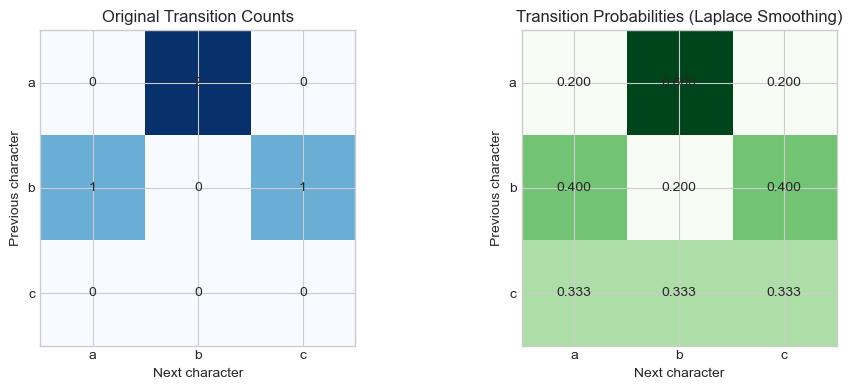

In [6]:
# ====================== 2.1 一阶马尔可夫模型 拉普拉斯平滑条件概率计算 ======================
# 题目给定序列与词汇表
sequence = "ababc"
vocab = ['a', 'b', 'c']
V_size = len(vocab)  # 词汇表大小，用于平滑

# 步骤1：初始化所有可能的转移计数（包含未出现的转移）
transition_counts = np.zeros((V_size, V_size))
char2idx = {c: i for i, c in enumerate(vocab)}

# 步骤2：遍历序列统计实际转移次数
for i in range(len(sequence) - 1):
    prev_idx = char2idx[sequence[i]]
    next_idx = char2idx[sequence[i + 1]]
    transition_counts[prev_idx, next_idx] += 1

# 步骤3：拉普拉斯平滑计算条件概率矩阵
prev_totals = transition_counts.sum(axis=1, keepdims=True)
transition_probs = (transition_counts + 1) / (prev_totals + V_size)

# 输出题目要求的两个概率
p_a_given_b = transition_probs[char2idx['b'], char2idx['a']]
p_c_given_b = transition_probs[char2idx['b'], char2idx['c']]

print("=== 原始转移计数矩阵（行:前一个字符, 列:下一个字符）===")
print(f"字符索引: {char2idx}")
print(transition_counts)
print(f"\n1. p('a' | 'b') = {p_a_given_b:.4f}")
print(f"2. p('c' | 'b') = {p_c_given_b:.4f}")

# ========== 可视化：平滑前后转移概率热力图对比 ==========
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 原始频率热力图
im0 = axes[0].imshow(transition_counts, cmap='Blues')
axes[0].set_xticks(range(V_size))
axes[0].set_xticklabels(vocab)
axes[0].set_yticks(range(V_size))
axes[0].set_yticklabels(vocab)
axes[0].set_title('Original Transition Counts')
axes[0].set_xlabel('Next character')
axes[0].set_ylabel('Previous character')
for i in range(V_size):
    for j in range(V_size):
        axes[0].text(j, i, int(transition_counts[i,j]), ha='center', va='center')

# 平滑后概率热力图
im1 = axes[1].imshow(transition_probs, cmap='Greens')
axes[1].set_xticks(range(V_size))
axes[1].set_xticklabels(vocab)
axes[1].set_yticks(range(V_size))
axes[1].set_yticklabels(vocab)
axes[1].set_title('Transition Probabilities (Laplace Smoothing)')
axes[1].set_xlabel('Next character')
axes[1].set_ylabel('Previous character')
for i in range(V_size):
    for j in range(V_size):
        axes[1].text(j, i, f'{transition_probs[i,j]:.3f}', ha='center', va='center')

plt.tight_layout()
plt.show()

词汇表（词: ID）： {'time': 0, 'machine': 1, 'the': 2, 'travel': 3, 'a': 4, 'can': 5, 'is': 6, 'novel': 7, 'through': 8}

特征序列示例（前3个）： [['the', 'time'], ['time', 'machine'], ['machine', 'is']]
标签序列示例（前3个）： ['machine', 'is', 'a']

总样本数：12


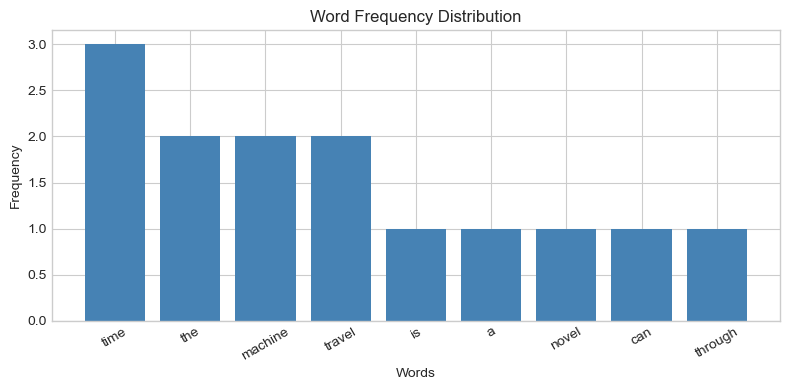

In [7]:
# ====================== 2.2 文本预处理函数 preprocess_text ======================
def preprocess_text(text, n):
    """
    文本预处理，生成自回归语言模型的特征-标签对
    参数:
        text: 输入原始文本字符串
        n: 滑动窗口长度（特征序列的词数）
    返回:
        vocab: 词汇表字典 {词: 整数ID}，按词频降序排序，ID从0开始
        (features, labels): 特征列表与对应标签列表，无后续词的样本自动忽略
    """
    # 步骤1：转小写，去除标点（仅保留字母和空格）
    text_lower = text.lower()
    text_clean = re.sub(r'[^a-z\s]', '', text_lower)
    
    # 步骤2：按空格分词
    words = text_clean.split()
    
    # 边界处理
    if len(words) < n + 1:
        word_freq = Counter(words)
        sorted_words = sorted(word_freq.keys(), key=lambda w: (-word_freq[w], w))
        vocab = {word: idx for idx, word in enumerate(sorted_words)}
        return vocab, ([], [])
    
    # 步骤3：构建词汇表：按词频降序排序
    word_freq = Counter(words)
    sorted_words = sorted(word_freq.keys(), key=lambda w: (-word_freq[w], w))
    vocab = {word: idx for idx, word in enumerate(sorted_words)}
    
    # 步骤4：滑动窗口生成特征与标签
    features = []
    labels = []
    for i in range(len(words) - n):
        feat_window = words[i : i + n]
        next_word = words[i + n]
        features.append(feat_window)
        labels.append(next_word)
    
    return vocab, (features, labels), word_freq

# ========== 测试：用更长的文本演示效果 ==========
test_text = "The time machine is a time travel novel. The machine can travel through time."
test_n = 2
vocab, (feats, labels), word_freq = preprocess_text(test_text, test_n)

print("词汇表（词: ID）：", vocab)
print("\n特征序列示例（前3个）：", feats[:3])
print("标签序列示例（前3个）：", labels[:3])
print(f"\n总样本数：{len(feats)}")

# ========== 可视化：词频排序柱状图 ==========
sorted_words = sorted(word_freq.items(), key=lambda x: -x[1])
words_list, counts = zip(*sorted_words)

plt.figure(figsize=(8, 4))
plt.bar(words_list, counts, color='steelblue')
plt.title('Word Frequency Distribution')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

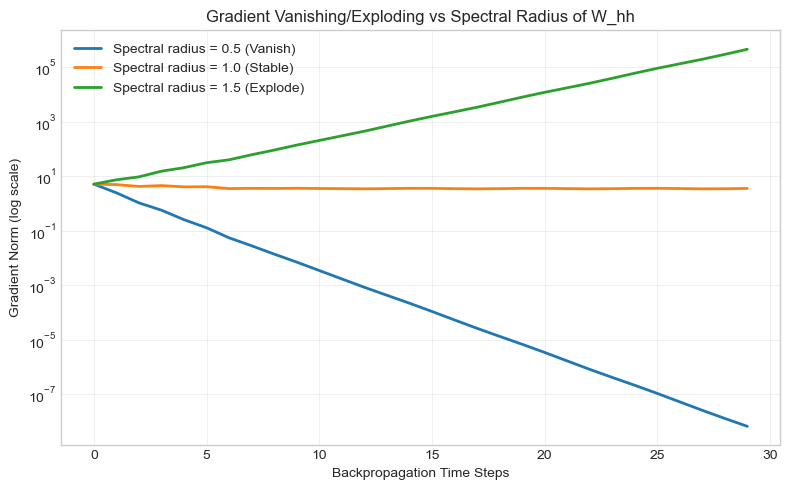

验证结论：
谱半径<1时，梯度随时间步指数衰减（梯度消失）
谱半径>1时，梯度随时间步指数增长（梯度爆炸）
谱半径=1时，梯度幅值保持相对稳定


In [8]:
# ====================== 3.1 线性RNN 沿时间反向传播(BPTT)梯度推导 + 数值验证 ======================
"""
### 模型定义
线性RNN（无偏置）：
    h_t = W_{hh} · h_{t-1} + W_{hx} · x_t
    o_t = W_{oh} · h_t
平方损失函数：
    L = 1/2 · Σ_{t=1}^T (o_t - y_t)²

### 梯度推导过程
1. 定义误差项 δ_t = ∂L/∂h_t
   输出层梯度：∂L/∂o_t = o_t - y_t
   反向递推公式：
       δ_T = W_{oh}^T · (o_T - y_T)
       δ_t = W_{oh}^T · (o_t - y_t) + W_{hh}^T · δ_{t+1}

2. 总梯度：∂L/∂W_{hh} = Σ_{t=1}^T δ_t · h_{t-1}^T

### 梯度消失与爆炸条件
梯度幅值由 W_{hh} 的谱半径决定：
- 谱半径 < 1 → 梯度指数衰减（梯度消失）
- 谱半径 > 1 → 梯度指数增长（梯度爆炸）
- 谱半径 ≈ 1 → 梯度稳定传播
"""

# ========== 数值验证：不同谱半径下的梯度反向传播衰减规律 ==========
hidden_size = 16
T = 30  # 反向传播时间步数

def adjust_spectral_radius(W, target_radius):
    """调整矩阵W的谱半径到目标值"""
    eigenvalues = np.linalg.eigvals(W)
    current_radius = np.max(np.abs(eigenvalues))
    return W * (target_radius / current_radius)

# 生成三个不同谱半径的权重矩阵
np.random.seed(42)
W_raw = np.random.randn(hidden_size, hidden_size)
W_decay = adjust_spectral_radius(W_raw, 0.5)   # 谱半径0.5 → 梯度消失
W_stable = adjust_spectral_radius(W_raw, 1.0)  # 谱半径1.0 → 稳定
W_explode = adjust_spectral_radius(W_raw, 1.5) # 谱半径1.5 → 梯度爆炸

# 初始时刻（最后一步）的误差梯度
delta_init = np.random.randn(hidden_size)

def compute_gradient_norms(W_hh, delta_0, steps):
    """反向递推计算每一步的梯度范数"""
    norms = []
    delta = delta_0.copy()
    for _ in range(steps):
        norms.append(np.linalg.norm(delta))
        delta = W_hh.T @ delta  # 反向传播一步
    return norms

# 计算三种情况的梯度范数变化
norms_decay = compute_gradient_norms(W_decay, delta_init, T)
norms_stable = compute_gradient_norms(W_stable, delta_init, T)
norms_explode = compute_gradient_norms(W_explode, delta_init, T)

# ========== 可视化：梯度幅值随反向传播步数的变化 ==========
plt.figure(figsize=(8, 5))
plt.plot(range(T), norms_decay, label='Spectral radius = 0.5 (Vanish)', linewidth=2)
plt.plot(range(T), norms_stable, label='Spectral radius = 1.0 (Stable)', linewidth=2)
plt.plot(range(T), norms_explode, label='Spectral radius = 1.5 (Explode)', linewidth=2)
plt.yscale('log')  # 对数坐标更清晰展示指数变化
plt.xlabel('Backpropagation Time Steps')
plt.ylabel('Gradient Norm (log scale)')
plt.title('Gradient Vanishing/Exploding vs Spectral Radius of W_hh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("验证结论：")
print("谱半径<1时，梯度随时间步指数衰减（梯度消失）")
print("谱半径>1时，梯度随时间步指数增长（梯度爆炸）")
print("谱半径=1时，梯度幅值保持相对稳定")

解析梯度与数值梯度的平均误差: 2.04e-11
误差小于1e-4说明反向传播实现正确


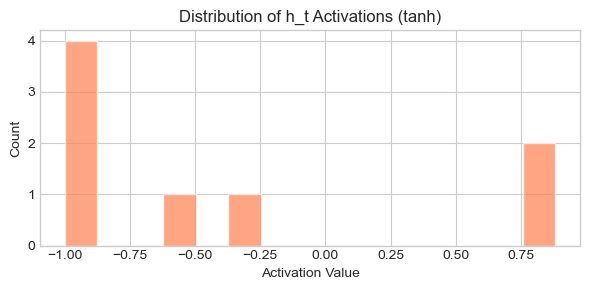

In [9]:
# ====================== 3.2 RNN单元前向+单步反向传播（tanh激活）+ 梯度校验 ======================
def rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """RNN单元前向传播"""
    z_t = np.dot(x_t, W_hx) + np.dot(h_prev, W_hh) + b_h
    h_t = np.tanh(z_t)
    cache = (x_t, h_prev, h_t, W_hx, W_hh)
    return h_t, cache

def rnn_cell_backward(dh_next, cache):
    """RNN单元单步反向传播"""
    x_t, h_prev, h_t, W_hx, W_hh = cache
    dz_t = dh_next * (1 - h_t ** 2)  # tanh导数
    
    db_h = np.sum(dz_t, axis=0)
    dW_hx = np.dot(x_t.T, dz_t)
    dW_hh = np.dot(h_prev.T, dz_t)
    dx_t = np.dot(dz_t, W_hx.T)
    dh_prev = np.dot(dz_t, W_hh.T)
    
    return dx_t, dh_prev, dW_hx, dW_hh, db_h

def numerical_gradient(param, forward_func, eps=1e-5):
    """数值梯度计算（有限差分法），用于校验解析梯度正确性"""
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        original = param[idx]
        
        param[idx] = original + eps
        h_plus, _ = forward_func()
        param[idx] = original - eps
        h_minus, _ = forward_func()
        param[idx] = original
        
        # 损失为h_t所有元素的和，对应dh_next全1
        grad[idx] = (np.sum(h_plus) - np.sum(h_minus)) / (2 * eps)
        it.iternext()
    return grad

# ========== 功能测试 + 梯度正确性校验 ==========
np.random.seed(42)
batch_size, input_size, hidden_size = 2, 3, 4

x_t = np.random.randn(batch_size, input_size)
h_prev = np.random.randn(batch_size, hidden_size)
W_hx = np.random.randn(input_size, hidden_size)
W_hh = np.random.randn(hidden_size, hidden_size)
b_h = np.random.randn(hidden_size)

# 前向传播
h_t, cache = rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h)
dh_next = np.ones_like(h_t)
dx_t, dh_prev, dW_hx, dW_hh, db_h = rnn_cell_backward(dh_next, cache)

# 数值梯度校验
forward_fn = lambda: rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h)
dW_hh_num = numerical_gradient(W_hh, forward_fn)
error = np.mean(np.abs(dW_hh - dW_hh_num))

print(f"解析梯度与数值梯度的平均误差: {error:.2e}")
print("误差小于1e-4说明反向传播实现正确")

# ========== 可视化：隐藏状态激活值分布 ==========
plt.figure(figsize=(6, 3))
plt.hist(h_t.flatten(), bins=15, color='coral', alpha=0.7, edgecolor='white')
plt.title('Distribution of h_t Activations (tanh)')
plt.xlabel('Activation Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

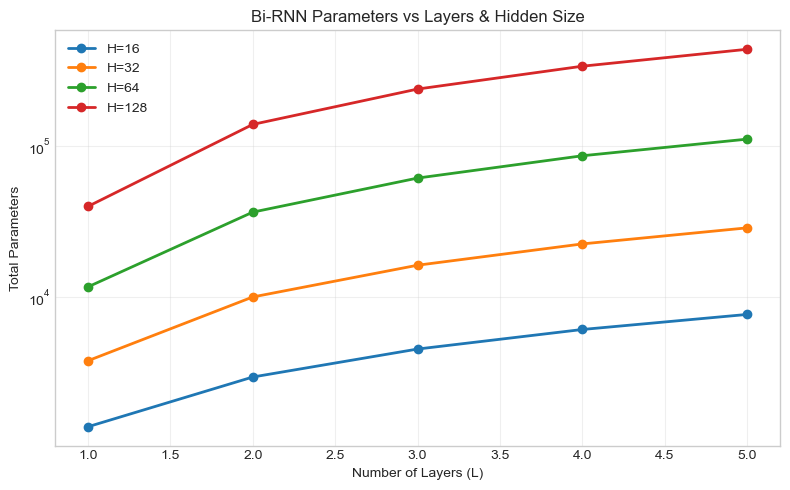

L=2, H=32, D=16, O=10 → 总参数: 9994


In [10]:
# ====================== 4.1 深度双向RNN 参数总数推导 + 可视化 ======================
"""
### 总参数公式
总参数 = 第1层双向参数 + (L-1)层中间层双向参数 + 输出层参数
       = 2H(D + H + 1) + (L-1)·2H(3H + 1) + O(2H + 1)
"""

def count_bi_rnn_params(L, H, D, O):
    """计算深度双向RNN总参数量"""
    layer1 = 2 * H * (D + H + 1)
    middle = (L - 1) * 2 * H * (3 * H + 1) if L > 1 else 0
    output = O * (2 * H + 1)
    return layer1 + middle + output

# ========== 可视化：不同层数和隐藏单元下的参数量变化 ==========
D, O = 16, 10
H_list = [16, 32, 64, 128]
L_range = range(1, 6)

plt.figure(figsize=(8, 5))
for H in H_list:
    params = [count_bi_rnn_params(L, H, D, O) for L in L_range]
    plt.plot(L_range, params, marker='o', label=f'H={H}', linewidth=2)

plt.xlabel('Number of Layers (L)')
plt.ylabel('Total Parameters')
plt.yscale('log')
plt.title('Bi-RNN Parameters vs Layers & Hidden Size')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 题目示例计算
L, H, D, O = 2, 32, 16, 10
total = count_bi_rnn_params(L, H, D, O)
print(f"L={L}, H={H}, D={D}, O={O} → 总参数: {total}")

逐时间步输出形状: torch.Size([8, 1, 8])  (seq_len, batch, 2*hidden_dim)
最终序列表示形状: torch.Size([1, 8])  (batch, 2*hidden_dim)


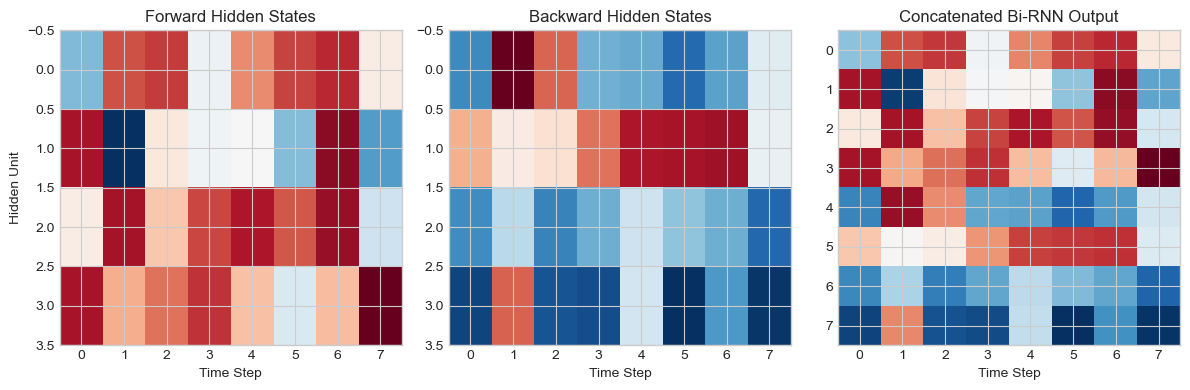

In [11]:
# ====================== 4.2 双向RNN编码器实现 + 隐藏状态可视化 ======================
class BiRNNEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.rnn = nn.RNN(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False
        )
    
    def forward(self, X):
        output, h_n = self.rnn(X)
        h_n_reshaped = h_n.view(self.num_layers, 2, X.size(1), self.hidden_dim)
        forward_final = h_n_reshaped[-1, 0]
        backward_final = h_n_reshaped[-1, 1]
        final_hidden = torch.cat([forward_final, backward_final], dim=-1)
        return output, final_hidden

# ========== 功能测试 ==========
seq_len, batch, input_dim, hidden_dim = 8, 1, 6, 4
torch.manual_seed(42)
encoder = BiRNNEncoder(input_dim, hidden_dim)
X = torch.randn(seq_len, batch, input_dim)
output, final_hidden = encoder(X)

print(f"逐时间步输出形状: {output.shape}  (seq_len, batch, 2*hidden_dim)")
print(f"最终序列表示形状: {final_hidden.shape}  (batch, 2*hidden_dim)")

# ========== 可视化：前向/后向/拼接隐藏状态热力图 ==========
output_np = output.squeeze(1).detach().numpy()  # (seq_len, 2*hidden_dim)
forward_out = output_np[:, :hidden_dim]
backward_out = output_np[:, hidden_dim:]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

im0 = axes[0].imshow(forward_out.T, cmap='RdBu_r', aspect='auto')
axes[0].set_title('Forward Hidden States')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Hidden Unit')

im1 = axes[1].imshow(backward_out.T, cmap='RdBu_r', aspect='auto')
axes[1].set_title('Backward Hidden States')
axes[1].set_xlabel('Time Step')

im2 = axes[2].imshow(output_np.T, cmap='RdBu_r', aspect='auto')
axes[2].set_title('Concatenated Bi-RNN Output')
axes[2].set_xlabel('Time Step')

plt.tight_layout()
plt.show()

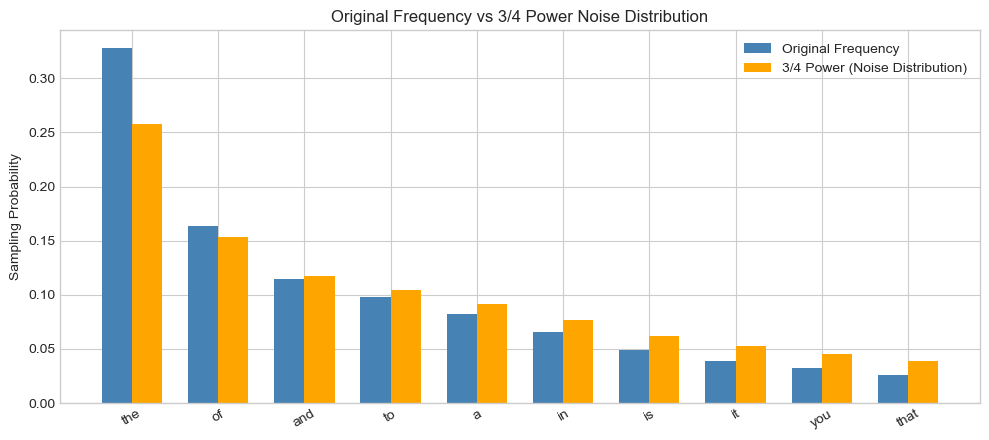

结论：3/4次方降低了高频词的采样概率，提升了低频词的采样概率，分布更平滑


In [12]:
# ====================== 5.1 Skip-gram 负采样损失推导 + 噪声分布可视化 ======================
"""
### 负采样损失函数（单个中心词-上下文对）
L = - [ log σ(u_o^T v_c) + Σ_{k=1}^K log σ(-u_{n_k}^T v_c) ]

### 负采样噪声分布
P(w) = count(w)^{3/4} / Σ count(w')^{3/4}
3/4次方用于平滑词频，缓解高频词过度采样问题
"""

# ========== 可视化：原始词频 vs 3/4次方噪声分布对比 ==========
# 模拟真实语料的词频分布（齐普夫定律）
vocab_demo = ['the', 'of', 'and', 'to', 'a', 'in', 'is', 'it', 'you', 'that']
freq_raw = np.array([10000, 5000, 3500, 3000, 2500, 2000, 1500, 1200, 1000, 800])

# 计算3/4次方后的采样概率
freq_power = freq_raw ** 0.75
prob_raw = freq_raw / freq_raw.sum()
prob_power = freq_power / freq_power.sum()

x = np.arange(len(vocab_demo))
width = 0.35

plt.figure(figsize=(10, 4.5))
plt.bar(x - width/2, prob_raw, width, label='Original Frequency', color='steelblue')
plt.bar(x + width/2, prob_power, width, label='3/4 Power (Noise Distribution)', color='orange')

plt.xticks(x, vocab_demo, rotation=30)
plt.ylabel('Sampling Probability')
plt.title('Original Frequency vs 3/4 Power Noise Distribution')
plt.legend()
plt.tight_layout()
plt.show()

print("结论：3/4次方降低了高频词的采样概率，提升了低频词的采样概率，分布更平滑")

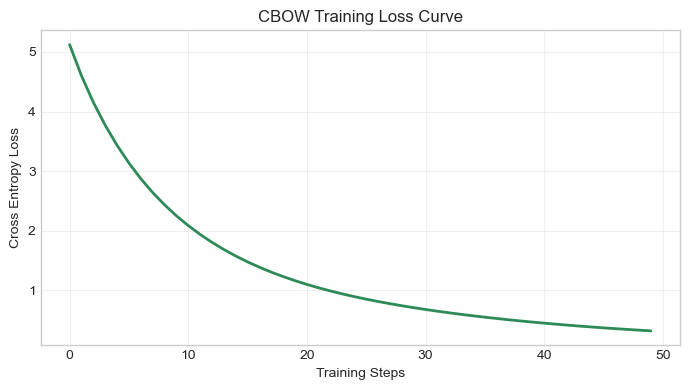

初始损失: 5.1214
最终损失: 0.3210


In [13]:
# ====================== 5.2 CBOW模型前向传播 + 简单训练损失曲线 ======================
def cbow_forward(context_indices, target_indices, W, W_out):
    """CBOW前向传播与交叉熵损失计算"""
    batch_size = context_indices.shape[0]
    context_embeds = W[context_indices]
    h = torch.mean(context_embeds, dim=1)
    scores = torch.matmul(h, W_out)
    
    # 数值稳定softmax + 交叉熵
    log_probs = torch.log_softmax(scores, dim=1)
    loss = -log_probs[torch.arange(batch_size), target_indices].mean()
    return loss

# ========== 简单训练演示：观察损失下降 ==========
V, d, context_size, batch_size = 20, 8, 2, 16
torch.manual_seed(42)

# 初始化可训练权重
W = torch.randn(V, d, requires_grad=True)
W_out = torch.randn(d, V, requires_grad=True)
optimizer = torch.optim.SGD([W, W_out], lr=0.5)

# 构造模拟数据
context_idx = torch.randint(0, V, (batch_size, context_size))
target_idx = torch.randint(0, V, (batch_size,))

loss_history = []
steps = 50

for step in range(steps):
    optimizer.zero_grad()
    loss = cbow_forward(context_idx, target_idx, W, W_out)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# ========== 可视化：损失下降曲线 ==========
plt.figure(figsize=(7, 4))
plt.plot(range(steps), loss_history, color='seagreen', linewidth=2)
plt.xlabel('Training Steps')
plt.ylabel('Cross Entropy Loss')
plt.title('CBOW Training Loss Curve')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"初始损失: {loss_history[0]:.4f}")
print(f"最终损失: {loss_history[-1]:.4f}")

=== 步骤1：得分矩阵 QK^T/√d_k ===
[[ 0.2509  0.0725  0.099 ]
 [ 0.0483 -1.8634 -1.4245]]

=== 步骤2：注意力权重（softmax）===
[[0.371  0.3104 0.3187]
 [0.7262 0.1073 0.1665]]

=== 步骤3：加权求和输出 ===
[[ 0.5165  0.6492 -0.1531  0.5548 -0.0559]
 [ 0.9868  0.6759 -0.2414  0.7158  0.0918]]


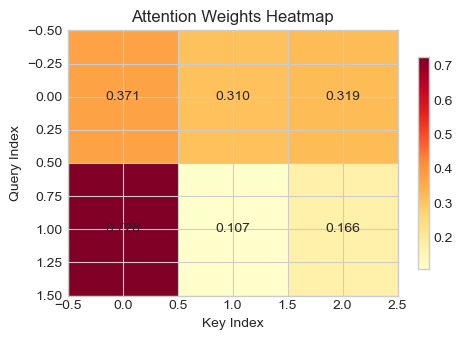

In [14]:
# ====================== 6.1 缩放点积注意力 分步计算 + 热力图 ======================
def scaled_dot_product_attention(Q, K, V, d_k):
    """缩放点积注意力完整流程"""
    scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))
    attn_weights = torch.softmax(scores, dim=-1)
    output = torch.matmul(attn_weights, V)
    return output, attn_weights, scores

# ========== 按题目维度计算 ==========
torch.manual_seed(42)
d_k = 4
Q = torch.randn(2, 4)  # 2个查询
K = torch.randn(3, 4)  # 3个键
V = torch.randn(3, 5)  # 3个值

output, attn_weights, scores = scaled_dot_product_attention(Q, K, V, d_k)

print("=== 步骤1：得分矩阵 QK^T/√d_k ===")
print(scores.numpy().round(4))
print("\n=== 步骤2：注意力权重（softmax）===")
print(attn_weights.numpy().round(4))
print("\n=== 步骤3：加权求和输出 ===")
print(output.numpy().round(4))

# ========== 可视化：注意力权重热力图 ==========
plt.figure(figsize=(5, 3.5))
plt.imshow(attn_weights.numpy(), cmap='YlOrRd', aspect='auto')
plt.title('Attention Weights Heatmap')
plt.xlabel('Key Index')
plt.ylabel('Query Index')
for i in range(2):
    for j in range(3):
        plt.text(j, i, f'{attn_weights[i,j].item():.3f}', ha='center', va='center')
plt.colorbar(shrink=0.8)
plt.tight_layout()
plt.show()

输入形状: torch.Size([6, 1, 4])
输出形状: torch.Size([6, 1, 4])
注意力权重形状: torch.Size([2, 1, 6, 6])  (num_heads, batch, seq_len, seq_len)


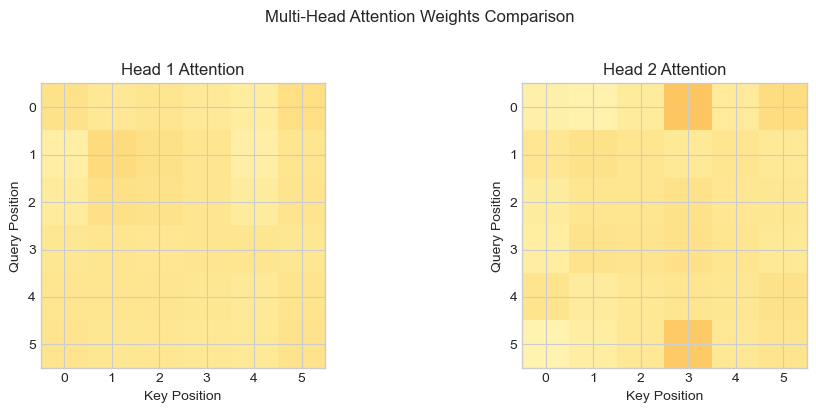

In [15]:
# ====================== 6.2 多头注意力前向传播 + 多头对比可视化 ======================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, X, return_attn=False):
        seq_len, batch, _ = X.shape
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        
        # 拆分为多头
        Q = Q.view(seq_len, batch, self.num_heads, self.d_k).permute(2, 1, 0, 3)
        K = K.view(seq_len, batch, self.num_heads, self.d_k).permute(2, 1, 0, 3)
        V = V.view(seq_len, batch, self.num_heads, self.d_k).permute(2, 1, 0, 3)
        
        # 缩放点积注意力
        scores = torch.matmul(Q, K.transpose(-2, -1)) / torch.sqrt(torch.tensor(self.d_k, dtype=torch.float32))
        attn_weights = torch.softmax(scores, dim=-1)
        head_outputs = torch.matmul(attn_weights, V)
        
        # 拼接+输出投影
        head_outputs = head_outputs.permute(2, 1, 0, 3).contiguous()
        concat_output = head_outputs.view(seq_len, batch, self.d_model)
        output = self.W_o(concat_output)
        
        if return_attn:
            return output, attn_weights
        return output

# ========== 题目参数测试 ==========
d_model = 4
num_heads = 2
seq_len, batch = 6, 1

torch.manual_seed(42)
mha = MultiHeadAttention(d_model, num_heads)
X = torch.randn(seq_len, batch, d_model)
output, attn_weights = mha(X, return_attn=True)

print(f"输入形状: {X.shape}")
print(f"输出形状: {output.shape}")
print(f"注意力权重形状: {attn_weights.shape}  (num_heads, batch, seq_len, seq_len)")

# ========== 可视化：两个头的注意力权重对比 ==========
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for head in range(num_heads):
    attn = attn_weights[head, 0].detach().numpy()
    im = axes[head].imshow(attn, cmap='YlOrRd', vmin=0, vmax=1)
    axes[head].set_title(f'Head {head+1} Attention')
    axes[head].set_xlabel('Key Position')
    axes[head].set_ylabel('Query Position')

plt.suptitle('Multi-Head Attention Weights Comparison', y=1.02)
plt.tight_layout()
plt.show()